In [46]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # Adds project root

In [47]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statistics import mode
import folium
from folium.plugins import MarkerCluster
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import random
from sklearn.impute import SimpleImputer
from typing import Dict
import seaborn as sns
from sklearn.impute import SimpleImputer
from IPython.display import display, HTML
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings("ignore")

In [48]:
from typing import List, Tuple
from Algorithms.CDREC import CDRec
from Algorithms.TKCM import TKCM
from Algorithms.TKCM_Weighted import TKCM_Weighted
from Algorithms.DynaMMO import DynaMMo
from Algorithms.SoftImpute import SoftImpute
from Algorithms.SVDImpute import IterativeSVD
from Algorithms.trmf import TRMFImputer
from Algorithms.ST_MVL import ST_MVL
from Algorithms.TKCM_PLUS import TKCM_PLUS
from Algorithms.TKCM_PRO import TKCM_PRO


In [49]:

# # Load dataset
mountain_df = pd.read_csv("D:\\Thesis\\Project\\Data\\mountain_data.csv")

# Count different types of missingness
stats = {
    "Total Rows": len(mountain_df),
    "Total Columns": len(mountain_df.columns),
    "Zero Values": (mountain_df == 0).sum().sum(),
    "NaN Values": mountain_df.isna().sum().sum(),
    "Blank Strings": (mountain_df == "").sum().sum(),
    "Unknown Strings": (mountain_df.applymap(lambda x: isinstance(x, str) and x.strip().lower() == "unknown")).sum().sum()
}

# Return as DataFrame
stats_df = pd.DataFrame(list(stats.items()), columns=["Metric", "Value"])
stats_df


,Metric,Value
0,Total Rows,2785482
1,Total Columns,6
2,Zero Values,96350
3,NaN Values,0
4,Blank Strings,0
5,Unknown Strings,0


In [50]:
mountain_df.head()

,station_code,sensor_code,description_it,unit,timestamp,value
0,45200SF,LT,Temperatura dell´aria,°C,2025-01-01 00:00:00,-2.1
1,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 23:30:00,-0.8
2,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 23:00:00,-2.2
3,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 22:30:00,-0.6
4,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 22:00:00,-1.0


In [51]:
mountain_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2785482 entries, 0 to 2785481
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   station_code    object 
 1   sensor_code     object 
 2   description_it  object 
 3   unit            object 
 4   timestamp       object 
 5   value           float64
dtypes: float64(1), object(5)
memory usage: 127.5+ MB


In [52]:
mountain_df.describe()

,value
count,2.785482e+06
mean,5.304164e+01
std,8.350127e+01
min,-2.460000e+01
25%,1.200000e+00
50%,8.200000e+00
75%,7.700000e+01
max,3.660000e+02


In [53]:
# Preview data
print("🔍 Shape:", mountain_df.shape)

🔍 Shape: (2785482, 6)


In [54]:
# Check which columns are non-numeric
print("🧠 Columns in the file:\n", mountain_df.dtypes)

🧠 Columns in the file:
 station_code       object
sensor_code        object
description_it     object
unit               object
timestamp          object
value             float64
dtype: object


In [55]:
unique_values = mountain_df['sensor_code'].unique()
unique_values

array(['LT', 'WR', 'WG', 'WG.BOE', 'LF', 'HS', 'N'], dtype=object)

In [56]:
unique_values1 = mountain_df['station_code'].unique()
unique_values1

array(['45200SF', '82500WS', '45100WS', '00700WS', '00390SF', '06040WS',
       '06090SF', '35100WS', '50400WS', '50360SF', '61690SF', '61720WS',
       '20720WS', '20690SF', '91210WS', '91180SF', '24300SF', '78480SF',
       '15000SF', '34200WS', '31810SF', '66000WS', '66100SF', '80100SF',
       '90005SF', '15050WS', '07740WS', '15590SF', '01080SF', '20050SF',
       '35205SF', '24170WS', '53200SF', '42830SF', '62270SF', '02700SF'],
      dtype=object)

In [57]:
unique_values2 = mountain_df['description_it'].unique()
unique_values2

array(['Temperatura dell´aria', 'Direzione del vento',
       'Velocità del vento', 'Velocitá raffica', 'Umidità relativa',
       'Altezza neve al suolo', 'Precipitazioni'], dtype=object)

In [58]:
unique_values3 = mountain_df['unit'].unique()
unique_values3

array(['°C', '° ', 'm/s', '%', 'cm', 'mm'], dtype=object)

In [59]:
unique_values4 = mountain_df['value'].unique()
unique_values4

array([ -2.1,  -0.8,  -2.2, ..., 327.3, 366. , 365. ], shape=(3847,))

In [60]:
column_names = list(mountain_df.columns)
column_names

['station_code', 'sensor_code', 'description_it', 'unit', 'timestamp', 'value']

In [61]:
zero_counts = (mountain_df == 0).sum()
print(zero_counts)

station_code          0
sensor_code           0
description_it        0
unit                  0
timestamp             0
value             96350
dtype: int64


In [62]:
mountain_df[mountain_df["value"] == 0].head()

,station_code,sensor_code,description_it,unit,timestamp,value
38,45200SF,LT,Temperatura dell´aria,°C,2024-12-31 05:00:00,0.0
57,45200SF,LT,Temperatura dell´aria,°C,2024-12-30 19:30:00,0.0
93,45200SF,LT,Temperatura dell´aria,°C,2024-12-30 01:30:00,0.0
247,45200SF,LT,Temperatura dell´aria,°C,2024-12-26 20:30:00,0.0
1403,45200SF,LT,Temperatura dell´aria,°C,2024-12-02 18:30:00,0.0


In [63]:
# Make sure 'value' is numeric
mountain_df['value'] = pd.to_numeric(mountain_df['value'], errors='coerce')

# Group by sensor_code
zero_stats = (
    mountain_df.groupby('sensor_code')
    .agg(
        total_entries=('value', 'count'),
        zero_count=('value', lambda x: (x == 0).sum())
    )
)

# Add percentage of zeros
zero_stats['zero_percentage'] = (zero_stats['zero_count'] / zero_stats['total_entries']) * 100

# Sort by percentage of zero values
zero_stats = zero_stats.sort_values(by='zero_percentage', ascending=False)

print(zero_stats.reset_index())


  sensor_code  total_entries  zero_count  zero_percentage
0           N           3165        3085        97.472354
1          WG         485833       45854         9.438223
2      WG.BOE         485834       37041         7.624209
3          WR         486667        5332         1.095616
4          LT         502908        3974         0.790204
5          HS         318145        1064         0.334439
6          LF         502930           0         0.000000


In [64]:
# Step 1: Select sensor `LF`
lt_df = mountain_df[mountain_df['sensor_code'] == 'LT'].copy()

In [65]:
# Step 2: Replace `0.0` values with NaN
#lt_df.loc[lt_df['value'] == 0.0, 'value'] = np.nan

In [66]:
# Step 3: Pivot to wide format (timestamp × station_code)
lt_df['timestamp'] = pd.to_datetime(lt_df['timestamp'])
pivot_df = lt_df.pivot(index='timestamp', columns='station_code', values='value')

In [67]:
# Step 4: Drop sparse stations (>10% missing)
threshold = 0.9 * len(pivot_df)
pivot_df = pivot_df.dropna(thresh=threshold, axis=1)

In [68]:
# Step 5: Drop rows with any missing values
clean_df = pivot_df.dropna(axis=0)

In [69]:
clean_df

station_code,00390SF,00700WS,01080SF,02700SF,06090SF,07740WS,15000SF,15590SF,20050SF,20690SF,...,61720WS,62270SF,66000WS,66100SF,78480SF,80100SF,82500WS,90005SF,91180SF,91210WS
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,-1.8,-1.0,2.9,1.6,2.6,0.5,0.0,-1.0,-2.3,-1.2,...,0.4,0.5,0.3,-1.3,1.0,-1.1,-0.8,-2.0,1.2,-1.1
2023-01-01 00:30:00,-2.2,-0.1,2.3,0.5,1.7,1.2,0.0,-1.0,-2.8,-1.7,...,1.7,0.7,0.2,-0.9,1.4,-1.0,-0.8,-1.4,-1.3,-0.9
2023-01-01 01:00:00,-1.8,-0.6,3.2,1.7,2.4,0.4,0.3,-1.0,-2.5,-1.5,...,2.1,1.1,0.0,-0.9,1.7,-0.9,-0.8,-1.4,-1.4,-0.1
2023-01-01 01:30:00,-2.5,0.6,3.0,2.8,1.7,0.6,0.8,-1.2,-3.3,-1.6,...,2.2,0.6,-0.2,-0.8,0.7,-0.8,-0.8,-1.3,-1.2,0.2
2023-01-01 02:00:00,-2.9,-0.8,2.4,2.1,2.0,0.9,0.1,-1.4,-3.1,-1.3,...,1.9,0.3,-0.6,-0.8,0.8,-0.7,-0.7,-0.8,-0.9,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,-4.6,-3.7,-1.5,-3.9,-3.6,-0.4,-6.3,-0.8,-2.1,0.4,...,-2.5,-0.4,-1.7,0.6,0.0,-2.2,0.0,-1.9,0.3,-3.3
2024-12-31 22:30:00,-5.2,-3.6,-1.6,-3.2,-3.6,-0.5,-6.5,-1.0,-2.9,0.2,...,-3.1,-0.4,-1.6,0.8,0.1,-1.7,0.0,-0.8,0.0,-3.8
2024-12-31 23:00:00,-4.9,-3.7,-1.7,-3.7,-3.0,-0.5,-5.7,-1.1,-4.0,0.0,...,-3.0,-0.3,-1.9,0.2,-0.1,-1.8,0.0,-1.5,-0.2,-3.8


In [70]:
# Step 6: Pick a target station (first available column)
target_station = clean_df.columns[2]

In [71]:
target_station

'01080SF'

In [72]:
# Step 7: Compute Pearson correlations with all other stations
correlations = clean_df.corr()[target_station].drop(index=target_station).sort_values(ascending=False)

In [73]:
correlations

station_code
07740WS    0.963428
15000SF    0.963066
66000WS    0.954931
42830SF    0.952816
00700WS    0.952574
02700SF    0.951485
20720WS    0.950659
62270SF    0.949221
06090SF    0.947076
24170WS    0.946432
91210WS    0.944073
61720WS    0.943638
45100WS    0.941387
34200WS    0.936710
66100SF    0.931119
53200SF    0.931114
31810SF    0.930363
82500WS    0.927434
78480SF    0.925450
35205SF    0.922040
61690SF    0.919933
35100WS    0.919530
80100SF    0.918944
45200SF    0.909692
91180SF    0.904420
20690SF    0.901905
20050SF    0.899161
90005SF    0.896624
15590SF    0.890313
00390SF    0.888495
50360SF    0.872446
24300SF    0.853997
Name: 01080SF, dtype: float64

In [74]:
# Step 8: Select top 2 correlated reference stations
top_refs = correlations.head(2).index.tolist()
final_df = clean_df[[target_station] + top_refs].copy()

In [75]:
top_refs

['07740WS', '15000SF']

In [76]:
final_df

station_code,01080SF,07740WS,15000SF
timestamp,,,
2023-01-01 00:00:00,2.9,0.5,0.0
2023-01-01 00:30:00,2.3,1.2,0.0
2023-01-01 01:00:00,3.2,0.4,0.3
2023-01-01 01:30:00,3.0,0.6,0.8
2023-01-01 02:00:00,2.4,0.9,0.1
...,...,...,...
2024-12-31 22:00:00,-1.5,-0.4,-6.3
2024-12-31 22:30:00,-1.6,-0.5,-6.5
2024-12-31 23:00:00,-1.7,-0.5,-5.7


In [77]:
# Step 8: Build new DataFrame with target and top 3 references
top_3_refs = correlations.dropna().sort_values(ascending=False).head(3).index.tolist()
selected_stations = [target_station] + top_3_refs
pattern_df = pivot_df[selected_stations].copy()

In [78]:
pattern_df

station_code,01080SF,07740WS,15000SF,66000WS
timestamp,,,,
2023-01-01 00:00:00,2.9,0.5,0.0,0.3
2023-01-01 00:30:00,2.3,1.2,0.0,0.2
2023-01-01 01:00:00,3.2,0.4,0.3,0.0
2023-01-01 01:30:00,3.0,0.6,0.8,-0.2
2023-01-01 02:00:00,2.4,0.9,0.1,-0.6
...,...,...,...,...
2024-12-31 22:00:00,-1.5,-0.4,-6.3,-1.7
2024-12-31 22:30:00,-1.6,-0.5,-6.5,-1.6
2024-12-31 23:00:00,-1.7,-0.5,-5.7,-1.9


In [79]:
pattern_df.isnull().sum()

station_code
01080SF    1
07740WS    1
15000SF    1
66000WS    1
dtype: int64

In [ ]:
for col in pattern_df.columns:
    if pattern_df[col].isnull().sum() > 0:
        print(f"\n🔍 Missing value in station {col}:")
        print(pattern_df[pattern_df[col].isnull()][col])



🔍 Missing value in station 01080SF:
timestamp
2023-02-14 14:30:00   NaN
Name: 01080SF, dtype: float64

🔍 Missing value in station 07740WS:
timestamp
2023-02-14 14:30:00   NaN
Name: 07740WS, dtype: float64

🔍 Missing value in station 15000SF:
timestamp
2023-02-14 14:30:00   NaN
Name: 15000SF, dtype: float64

🔍 Missing value in station 66000WS:
timestamp
2023-02-14 14:30:00   NaN
Name: 66000WS, dtype: float64


In [81]:
pattern_df = pattern_df.drop(index="2023-02-14 14:30:00")

In [82]:
print(pattern_df.columns.tolist())

['01080SF', '07740WS', '15000SF', '66000WS']


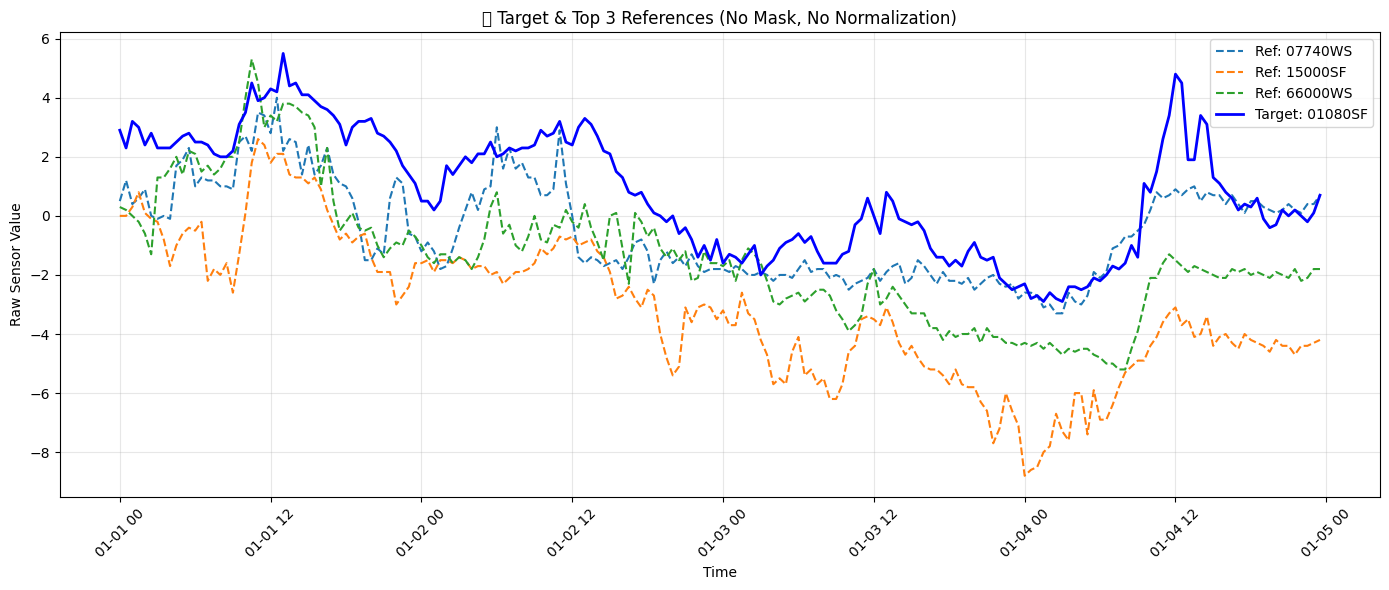

In [83]:
# Define the stations 
target = "01080SF"  # Target station
# References are the top 3 correlated stations
references = ["07740WS","15000SF","66000WS"]

# Define time range for plot (e.g., Jan 1 to Jan 4, 2023)
start_time = "2023-01-01"
end_time = "2023-01-04"

# Slice the DataFrame
plot_df = pattern_df[[target] + references].loc[start_time:end_time].copy()

# Plotting
plt.figure(figsize=(14, 6))

# Plot reference series
for ref in references:
    plt.plot(plot_df.index, plot_df[ref], linestyle='--', label=f"Ref: {ref}")

# Plot target series
plt.plot(plot_df.index, plot_df[target], color='blue', linewidth=2, label=f"Target: {target}")

plt.xlabel("Time")
plt.ylabel("Raw Sensor Value")
plt.title("📍 Target & Top 3 References (No Mask, No Normalization)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [84]:
# -------------------------------------------
# 🔹 STEP 1: Normalize the Time Series Data
# -------------------------------------------

from sklearn.preprocessing import StandardScaler

# 1️⃣ Initialize the Scaler
scaler = StandardScaler()

# 2️⃣ Fit the scaler on the full pattern_df and transform it
normalized_array = scaler.fit_transform(pattern_df)

# 3️⃣ Reconstruct a DataFrame with the same shape, columns, and index
normalized_df = pd.DataFrame(
    normalized_array,
    columns=pattern_df.columns,
    index=pattern_df.index
)

# 4️⃣ Print shape and preview
print("✅ Normalized shape:", normalized_df.shape)
display(normalized_df.head())


✅ Normalized shape: (14591, 4)


station_code,01080SF,07740WS,15000SF,66000WS
timestamp,,,,
2023-01-01 00:00:00,1.097980,0.695222,1.401801,1.052163
2023-01-01 00:30:00,0.978235,0.833345,1.401801,1.032494
2023-01-01 01:00:00,1.157852,0.675490,1.461425,0.993156
2023-01-01 01:30:00,1.117937,0.714954,1.560798,0.953818
2023-01-01 02:00:00,0.998193,0.774149,1.421676,0.875143


In [85]:
# ---------------------------------------------------------
# 🔹 STEP 2: Define function to inject single-missing in the middle
# ---------------------------------------------------------

def inject_single_point_middle(series: pd.Series, missing_ratio: float = 0.10, middle_fraction: float = 0.5, random_state: int = 42) -> Tuple[pd.Series, np.ndarray, np.ndarray]:
    """
    Inject NaNs randomly in the middle region of the series (e.g., middle 50%).

    Parameters:
        series (pd.Series): Original complete time series.
        missing_ratio (float): Proportion of points to mask (default = 0.1).
        middle_fraction (float): Fraction of series considered as "middle" (default = 0.5 = 50%).
        random_state (int): Seed for reproducibility.

    Returns:
        masked_series (pd.Series): Series with NaNs injected.
        missing_indices (np.ndarray): Indices where NaNs were inserted.
        true_values (np.ndarray): Original values at those indices.
    """
    ts = series.copy()
    n = len(ts)
    mid_start = int(n * (1 - middle_fraction) / 2)
    mid_end = int(n * (1 + middle_fraction) / 2)

    candidate_indices = np.arange(mid_start, mid_end)
    n_missing = int(len(candidate_indices) * missing_ratio)

    np.random.seed(random_state)
    missing_indices = np.random.choice(candidate_indices, size=n_missing, replace=False)
    true_values = ts.iloc[missing_indices].values

    ts.iloc[missing_indices] = np.nan
    return ts, missing_indices, true_values


In [ ]:
# ---------------------------------------------------------
# 🔹 STEP 2b: Apply single to the normalized target series
# ---------------------------------------------------------

# Define target station 
target_station = "01080SF"


# Apply the masking function for a single missing value in the middle
masked_target, missing_indices, true_vals = inject_single_point_middle(
    normalized_df[target_station], missing_ratio=0.10
)

# ✅ Optional: Print info about the missing point
print("🔢 Injected missing indices:", missing_indices)
print("📉 True values:", true_vals[:5])  # preview first 5
print("🕓 Corresponding timestamps:", normalized_df.index[missing_indices[:5]])

🔢 Injected missing indices: [ 7556  9651  5415  7007  8347  4512 10721  5880  5367  5309  5213  8788
 10911  9111  9995  9930 10066  4410  6944  6301  5836  7592  9653  4844
  4076  7918  7552  5963  8231 10733  5639 10887  4201  5552  5681  4862
  5262  4649  6035  9648  5180  8973  6411 10349  4143  6338 10860  9047
  9578  4475  7199  3708  5076  6617  7602  7768  7197  8836  4112  9283
 10598  7877  9792  5549  3832  6309  4579 10132  9157  5134  4731 10770
  9382  6586  5587  9128  6915  5350 10028  6891  8085  9196  7710  8916
 10738  6365  5387  8670  7641  3748  8152  4383 10758  4185  8167  8800
  4380  8865  3726  9455  6760  8925  6729  8586  3779  4384  4688  5742
 10846 10495  5281 10072  9174  9890 10254  6955  8373  8888  8759  6294
  6786  8886  3966  9504 10545  4489  5541  3824  8810  8318  7479  7608
  5156 10301  5824  7318  5402  5892  6840  4685 10206  7097  9091  7080
  6649  6163  7345  5692  7886  8357  5375  6966  9019  6418  8199  7026
  7504  9082  7751 1043

In [87]:
# ---------------------------------------------------------
# 🔹 STEP 3: Prepare NumPy arrays for imputation and evaluation
# ---------------------------------------------------------

# 1️⃣ Extract the reference station names (excluding the target)
reference_stations = [col for col in normalized_df.columns if col != target_station]

# 2️⃣ Get reference matrix as shape (num_refs, time) — transposed
ref_matrix = normalized_df[reference_stations].to_numpy().T  # shape: (num_refs, time)

# 3️⃣ Get the masked target series as array (shape: time,)
masked_target_array = masked_target.to_numpy().copy()

# 4️⃣ Get the original (true) unmasked target series
true_target_array = normalized_df[target_station].to_numpy()

# 5️⃣ Get the indices of missing values
missing_indices = np.where(np.isnan(masked_target_array))[0]
true_vals = true_target_array[missing_indices]

# ✅ Preview shapes and sanity check
print("🎯 Target shape:", masked_target_array.shape)
print("📘 Ref matrix shape:", ref_matrix.shape)
print("❓ Missing indices (preview):", missing_indices[:5])
print("🔍 True values at missing indices (preview):", true_vals[:5])

🎯 Target shape: (14591,)
📘 Ref matrix shape: (3, 14591)
❓ Missing indices (preview): [3664 3666 3678 3684 3688]
🔍 True values at missing indices (preview): [1.39734072 0.99819274 1.29755372 0.95827794 0.83853355]


In [88]:
# -----------------------------------------------
# 🔹 STEP 4.1: Set safe parameters for all models
# -----------------------------------------------

k = 5  # Number of top matching sequences (for TKCM-based methods)
l = 7  # Sliding window size for pattern matching (should be ≤ sequence length)

# 🧠 For matrix factorization-based methods (e.g., SVD, TRMF)
# Set a safe low-rank approximation based on the number of reference series
num_references = ref_matrix.shape[0]
rank = max(1, min(num_references - 1, 5))  # You can increase 2 → 5 for better modeling if safe



In [89]:
from sklearn.impute import SimpleImputer

# --- Basic Imputers ---

class ZeroImputer:
    def fit_transform(self, X):
        X = X.copy()
        X[np.isnan(X)] = 0
        return X


class MinImputer:
    def fit_transform(self, X):
        fill_value = np.nanmin(X[~np.isnan(X)])
        imp = SimpleImputer(strategy='constant', fill_value=fill_value)
        return imp.fit_transform(X)

class InterpolationImputer:
    def fit_transform(self, X):
        return pd.DataFrame(X).interpolate(method='linear', axis=0, limit_direction='both').values


In [90]:
# -----------------------------------------------
# 🔹 STEP 4.2: Apply each model with correct usage
# -----------------------------------------------



# Stack the masked target (first row) + full reference matrix (rest)
X_stacked = np.vstack([masked_target_array, ref_matrix])  # Shape: (1 + num_refs, time)

# -------------------
# TKCM-based Methods
# -------------------

# 1️⃣ TKCM
tkcm_imputed = masked_target_array.copy()
tkcm_model = TKCM(k=k, l=l)
for offset in missing_indices:
    tkcm_imputed = tkcm_model.impute(tkcm_imputed, offset=offset, ref_ts=ref_matrix)

# 2️⃣ TKCM_PLUS
tkcm_plus_imputed = masked_target_array.copy()
tkcm_plus_model = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.1)
for offset in missing_indices:
    tkcm_plus_imputed = tkcm_plus_model.impute(tkcm_plus_imputed, offset=offset, ref_ts=ref_matrix)

# 3️⃣ TKCM_Weighted
tkcm_weighted_imputed = masked_target_array.copy()
tkcm_weighted_model = TKCM_Weighted(k=k, l=l)
for offset in missing_indices:
    tkcm_weighted_imputed = tkcm_weighted_model.impute(tkcm_weighted_imputed, offset=offset, ref_ts=ref_matrix)

# 4️⃣ TKCM_PRO
tkcm_pro_imputed = masked_target_array.copy()
tkcm_pro_model = TKCM_PRO(k=k, l=l)
for offset in missing_indices:
    tkcm_pro_imputed = tkcm_pro_model.impute(tkcm_pro_imputed, offset=offset, ref_ts=ref_matrix)

# --------------------------
# Matrix Factorization Models
# --------------------------

# 5️⃣ CDRec
cdrec = CDRec(rank=rank)
cdrec_imputed = cdrec.impute(X_stacked.copy())[0]  # Only return target row

# 6️⃣ DynaMMo
dynammo = DynaMMo(latent_dim=rank)
dynammo_imputed = dynammo.fit_transform(X_stacked.copy())[0]

# 7️⃣ SoftImpute
soft = SoftImpute(max_rank=rank)
soft_imputed = soft.fit_transform(X_stacked.copy())[0]

# 8️⃣ IterativeSVD
svd = IterativeSVD(rank=rank)
svd_imputed = svd.fit_transform(X_stacked.copy())[0]

# 9️⃣ ST_MVL
st_mvl = ST_MVL()
st_mvl_imputed = st_mvl.impute(X_stacked.copy())[0]

# 🔟 TRMF
trmf = TRMFImputer(rank=rank)
trmf_imputed = trmf.fit_transform(X_stacked.copy())[0]

# --------------------
# Simple Baseline Models
# --------------------

# 1️⃣1️⃣ Zero Imputer
zero_imputer = ZeroImputer()
zero_imputed = zero_imputer.fit_transform(X_stacked.copy())[0]

# 1️⃣2️⃣ Min Imputer
min_imputer = MinImputer()
min_imputed = min_imputer.fit_transform(X_stacked.copy())[0]

# 1️⃣3️⃣ Interpolation Imputer
interp_imputer = InterpolationImputer()
interp_imputed = interp_imputer.fit_transform(X_stacked.copy())[0]


In [91]:

results_point = []

# ✅ New helper to evaluate predictions at multiple missing indices
def evaluate_pointwise(name, imputed_array, true_values, missing_indices):
    try:
        predicted_vals = imputed_array[missing_indices]
        if np.any(np.isnan(predicted_vals)):
            raise ValueError("Contains NaN")
        
        errors = predicted_vals - true_values
        mae = np.mean(np.abs(errors))
        rmse = np.sqrt(np.mean(errors ** 2))
        
        results_point.append({
            "Method": name,
            "Missing Points": len(missing_indices),
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4)
        })
    
    except Exception as e:
        print(f"❌ {name} failed: {e}")
        results_point.append({
            "Method": name,
            "Missing Points": len(missing_indices),
            "MAE": "NaN",
            "RMSE": "NaN"
        })


In [92]:
# Step 1: Stack masked target + reference
X_stmv = np.vstack([masked_target_array, ref_matrix])

# Step 2: Remove NaNs in references (only in reference rows)
X_stmv[1:, :] = np.nan_to_num(X_stmv[1:, :])

# Step 3: Run ST_MVL and evaluate at missing indices
try:
    st_mvl_model = ST_MVL()
    st_mvl_imputed = st_mvl_model.impute(X_stmv)[0]  # Only take imputed target row
    evaluate_pointwise("ST_MVL", st_mvl_imputed, true_vals, missing_indices)
except Exception as e:
    print("❌ ST_MVL failed:", e)
    fallback = np.full_like(masked_target_array, np.nan)
    evaluate_pointwise("ST_MVL", fallback, true_vals, missing_indices)



In [93]:
# Step 1: Prep TRMF input (shape = time x features)
X_trmf_input = np.vstack([masked_target_array, ref_matrix]).T.copy()

# Step 2: Generate mask and fill missing
observed_mask = ~np.isnan(X_trmf_input)
X_trmf_input = np.nan_to_num(X_trmf_input, nan=0.0).astype(np.float64)

# Step 3: Fit & transform
try:
    trmf_model = TRMFImputer(rank=rank, lag_idx=[1, 2, 3])
    trmf_model.fit(X_trmf_input, observed_mask)
    X_trmf_output = trmf_model.transform()

    trmf_imputed = X_trmf_output[:, 0]  # First column is the target
    evaluate_pointwise("TRMF", trmf_imputed, true_vals, missing_indices)

except Exception as e:
    print("❌ TRMF failed:", e)
    fallback = np.full_like(masked_target_array, np.nan)
    evaluate_pointwise("TRMF", fallback, true_vals, missing_indices)


In [94]:
# ✅ TKCM Variants — loop over all, support multiple missing
for method_name, model in {
    "TKCM": TKCM(k=k, l=l),
    "TKCM_PLUS": TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5),
    "TKCM_Weighted": TKCM_Weighted(k=k, l=l),
    "TKCM_PRO": TKCM_PRO(k=k, l=l),
}.items():
    try:
        # Impute once for all missing values (if supported)
        imputed_array = masked_target_array.copy()
        for offset in missing_indices:
            imputed_array = model.impute(imputed_array, offset=offset, ref_ts=ref_matrix)

        evaluate_pointwise(method_name, imputed_array, true_vals, missing_indices)

    except Exception as e:
        print(f"❌ {method_name} failed:", e)
        fallback = np.full_like(masked_target_array, np.nan)
        evaluate_pointwise(method_name, fallback, true_vals, missing_indices)

# ✅ Baseline Models (already computed externally)
baseline_models = {
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "Zero": zero_imputed,
    "Min": min_imputed,
    "Interpolation": interp_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
}

# ✅ Evaluate all models
for name, imputed_array in baseline_models.items():
    evaluate_pointwise(name, imputed_array, true_vals, missing_indices)

# ✅ Final Results Table
results_df = pd.DataFrame(results_point)
display(results_df.style.background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE"]))


,Method,Missing Points,MAE,RMSE
0,ST_MVL,729,0.196700,0.264400
1,TRMF,729,0.466300,0.575600
2,TKCM,729,0.161100,0.220600
3,TKCM_PLUS,729,0.532200,0.692000
4,TKCM_Weighted,729,0.160300,0.220200
5,TKCM_PRO,729,1.364400,1.687500
6,CDRec,729,0.149700,0.201300
7,DynaMMo,729,0.154900,0.208900
8,SoftImpute,729,0.147900,0.200200
9,SVDImpute,729,0.150100,0.200700


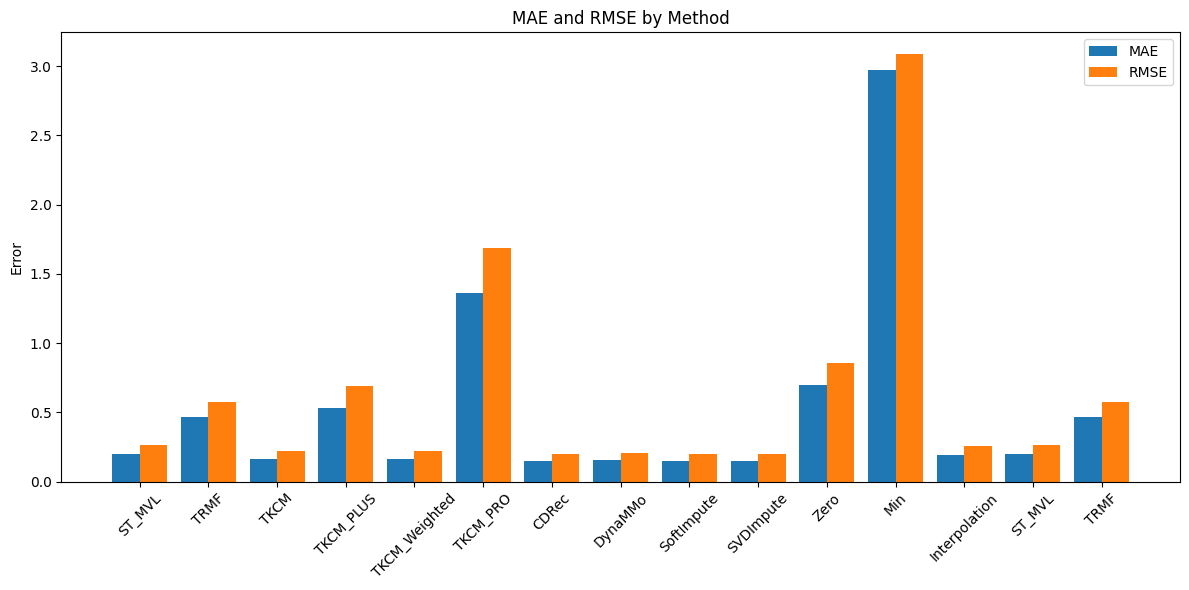

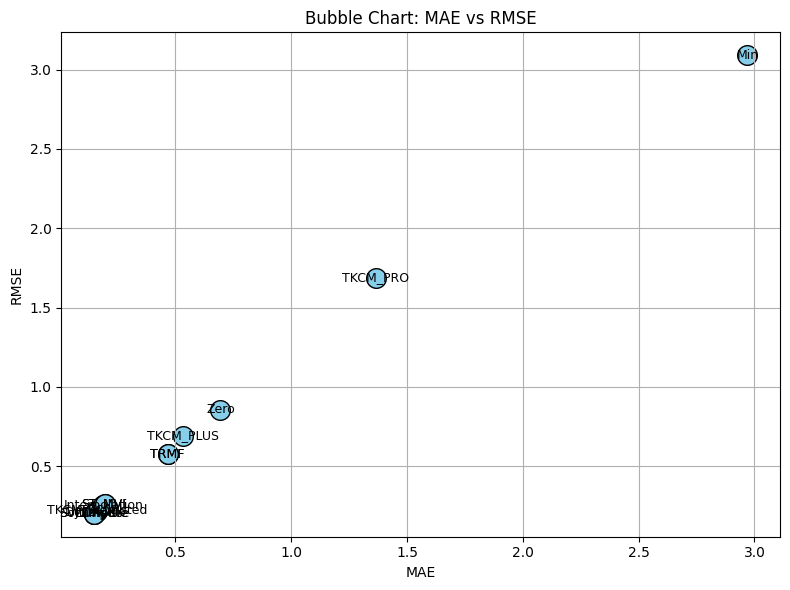

In [95]:
# Convert results_point to DataFrame for plotting
results_df = pd.DataFrame(results_point)

# Filter out methods with valid numeric values
plot_df = results_df[(results_df["MAE"] != "NaN") & (results_df["RMSE"] != "NaN")].copy()
plot_df["MAE"] = plot_df["MAE"].astype(float)
plot_df["RMSE"] = plot_df["RMSE"].astype(float)

# ------------------------
# 📊 Bar Plot: MAE & RMSE
# ------------------------
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.4
x = range(len(plot_df))

ax.bar([i - bar_width/2 for i in x], plot_df["MAE"], width=bar_width, label="MAE")
ax.bar([i + bar_width/2 for i in x], plot_df["RMSE"], width=bar_width, label="RMSE")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Method"], rotation=45)
ax.set_ylabel("Error")
ax.set_title("MAE and RMSE by Method")
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 🔵 Bubble Plot: MAE vs RMSE
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(plot_df["MAE"], plot_df["RMSE"],
                     s=200, c='skyblue', edgecolors='black')

# Annotate each point
for i, row in plot_df.iterrows():
    ax.annotate(row["Method"], (row["MAE"], row["RMSE"]), fontsize=9,
                ha='center', va='center')

ax.set_xlabel("MAE")
ax.set_ylabel("RMSE")
ax.set_title("Bubble Chart: MAE vs RMSE")
plt.grid(True)
plt.tight_layout()
plt.show()


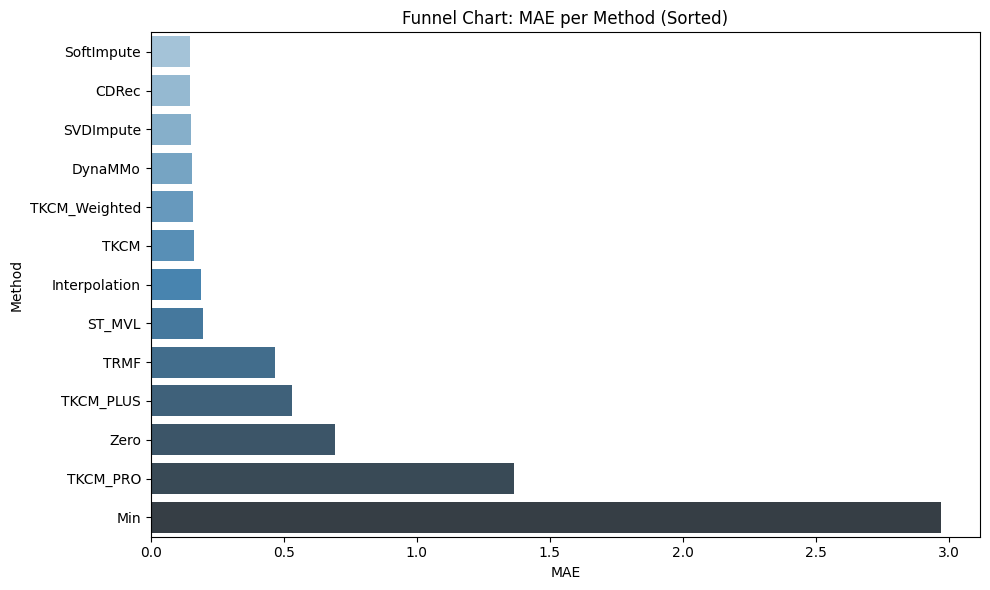

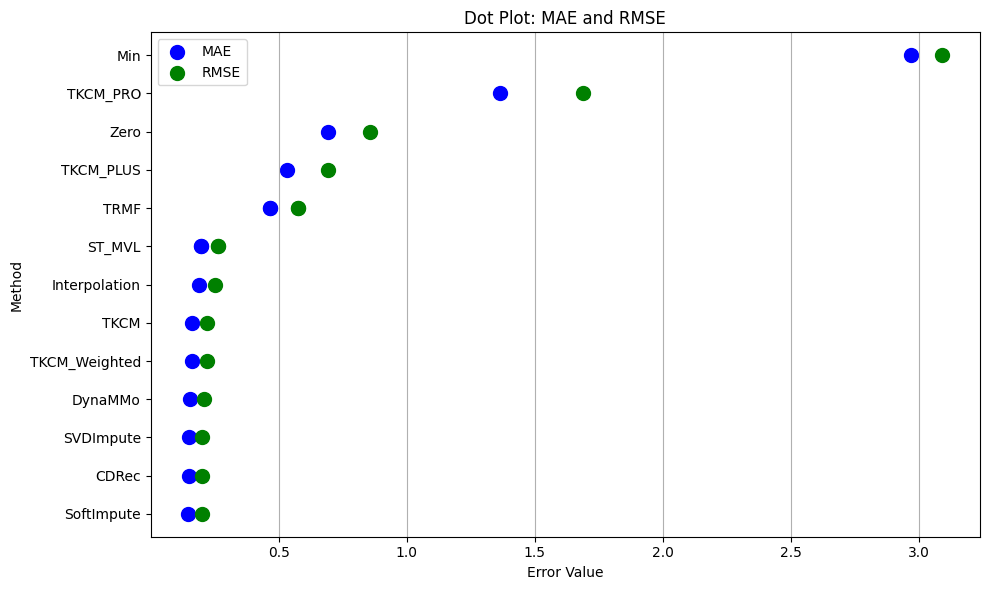

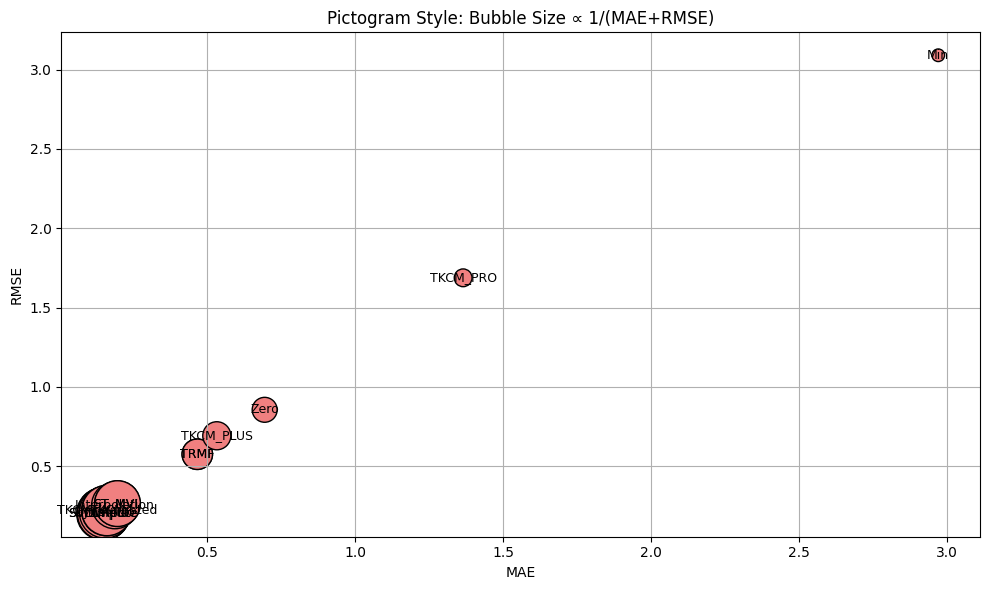

In [96]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Use existing plot_df from previous context
plot_df = results_df[(results_df["MAE"] != "NaN") & (results_df["RMSE"] != "NaN")].copy()
plot_df["MAE"] = plot_df["MAE"].astype(float)
plot_df["RMSE"] = plot_df["RMSE"].astype(float)

# Sort by MAE for consistent plotting
plot_df = plot_df.sort_values("MAE").reset_index(drop=True)

# --------------------------------------
# 📉 Funnel Plot: Sorted MAE per Method
# --------------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(x="MAE", y="Method", data=plot_df, palette="Blues_d")
plt.title("Funnel Chart: MAE per Method (Sorted)")
plt.xlabel("MAE")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

# ------------------------------
# 🎯 Dot Plot: MAE & RMSE Values
# ------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(plot_df["MAE"], plot_df["Method"], label="MAE", color="blue", s=100)
plt.scatter(plot_df["RMSE"], plot_df["Method"], label="RMSE", color="green", s=100)
plt.xlabel("Error Value")
plt.ylabel("Method")
plt.title("Dot Plot: MAE and RMSE")
plt.legend()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

# ---------------------------------
# 📦 Pictogram: Bubble-like Visual
# ---------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
sizes = 500 / (plot_df["MAE"] + plot_df["RMSE"])  # Inverse error = bigger is better

ax.scatter(plot_df["MAE"], plot_df["RMSE"], s=sizes, color='lightcoral', edgecolors='black')

for i, row in plot_df.iterrows():
    ax.annotate(row["Method"], (row["MAE"], row["RMSE"]), fontsize=9, ha='center', va='center')

ax.set_xlabel("MAE")
ax.set_ylabel("RMSE")
ax.set_title("Pictogram Style: Bubble Size ∝ 1/(MAE+RMSE)")
plt.grid(True)
plt.tight_layout()
plt.show()
